## Amazon ASP 추이 분석

### 미국

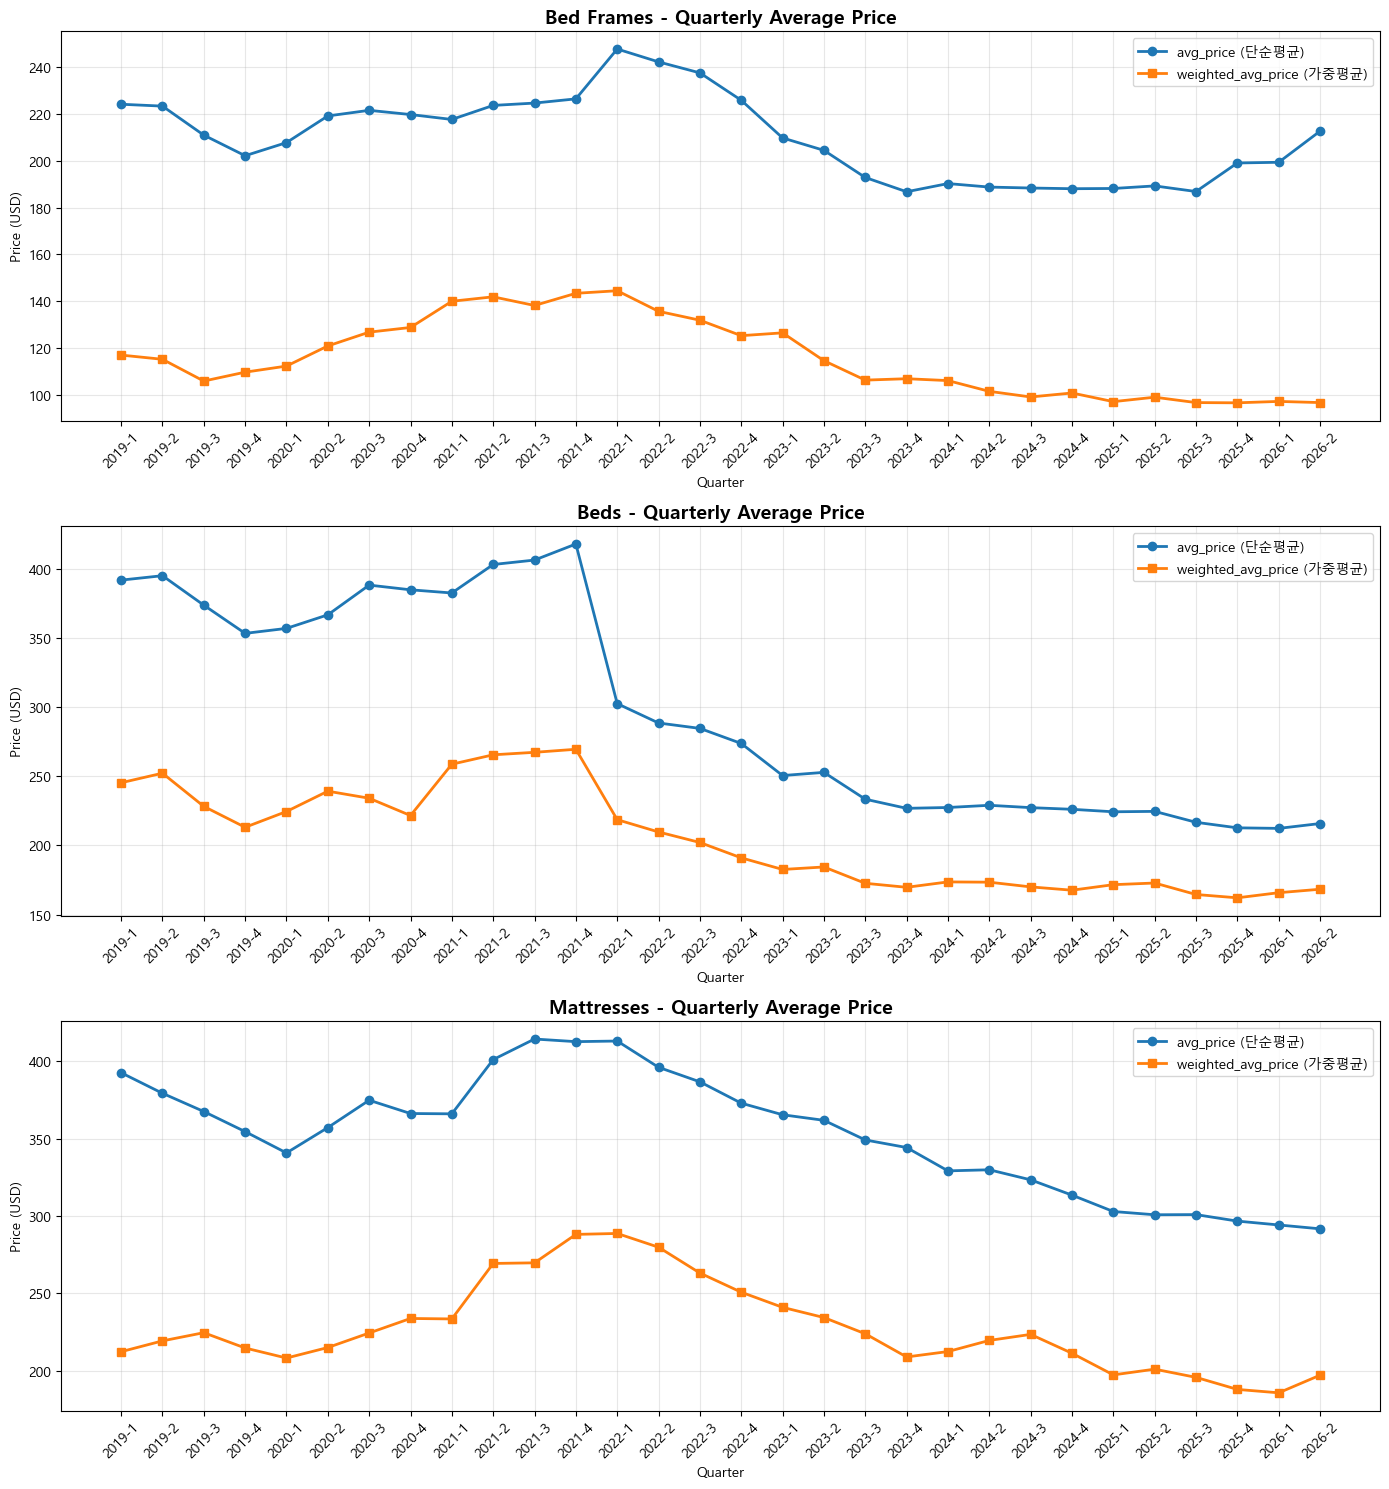

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1) 데이터 로드
df = pd.read_excel('amazon_avg_price_trend_0414.xlsx')
df = df.sort_values(['SubCategory', 'yr_qt'])

# 2) SubCategory별 subplot
subcategories = df['SubCategory'].unique()
n = len(subcategories)

fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, sub in zip(axes, subcategories):
    s = df[df['SubCategory'] == sub]
    ax.plot(s['yr_qt'], s['avg_price'],
            marker='o', linewidth=2, label='avg_price (단순평균)')
    ax.plot(s['yr_qt'], s['weighted_avg_price'],
            marker='s', linewidth=2, label='weighted_avg_price (가중평균)')

    ax.set_title(f'{sub} - Quarterly Average Price', fontsize=14, fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('amazon_avg_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### 유럽

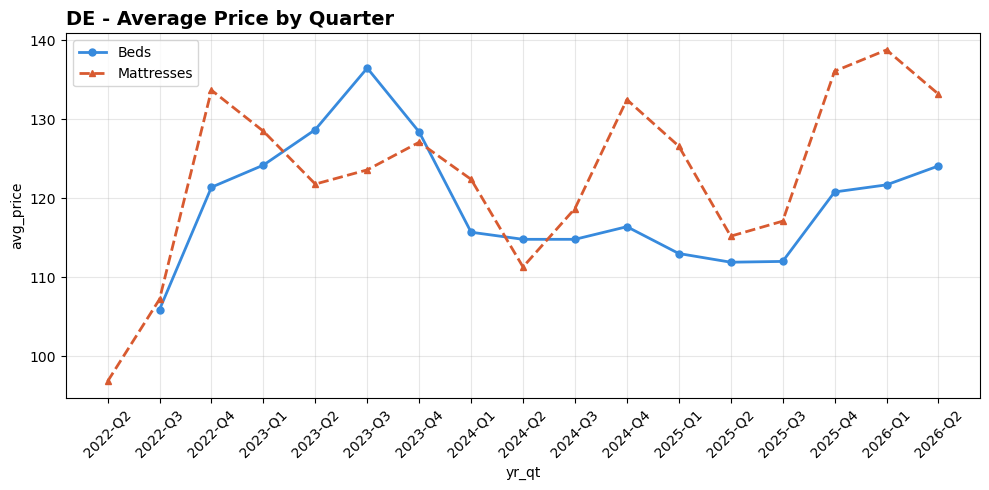

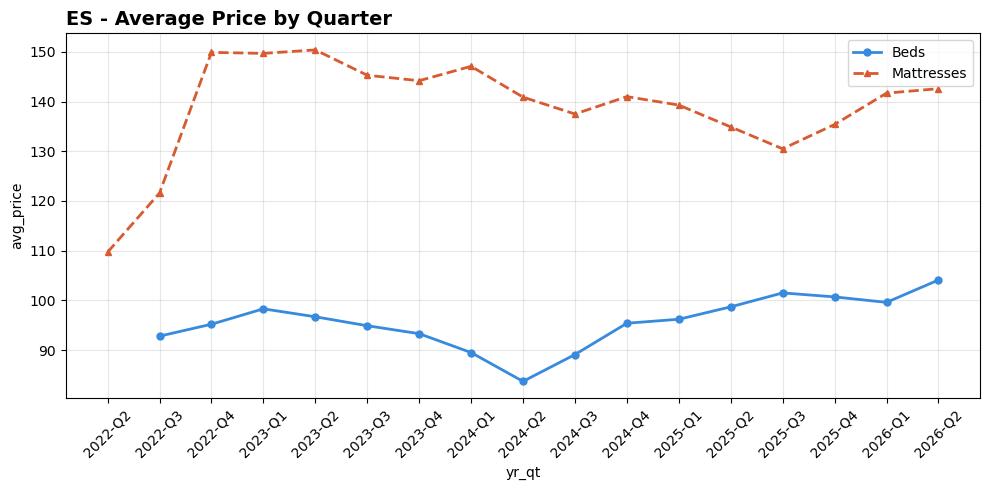

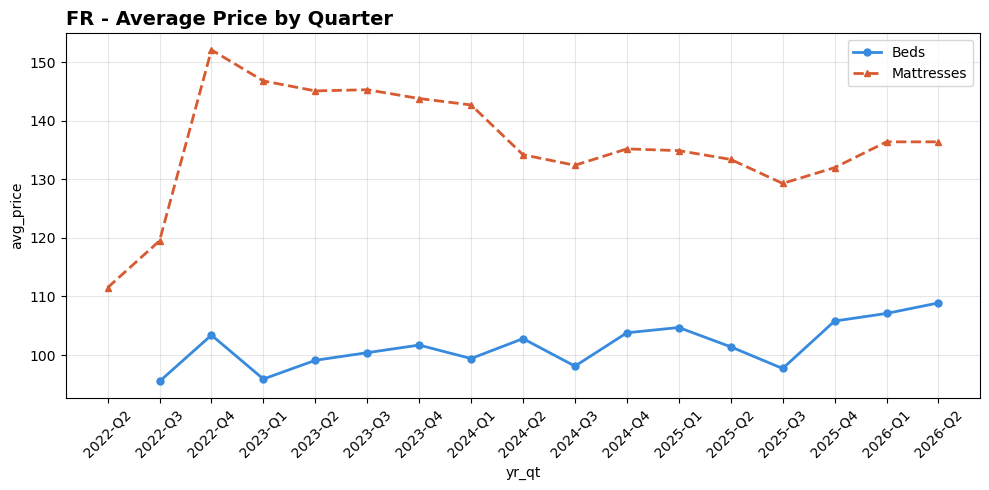

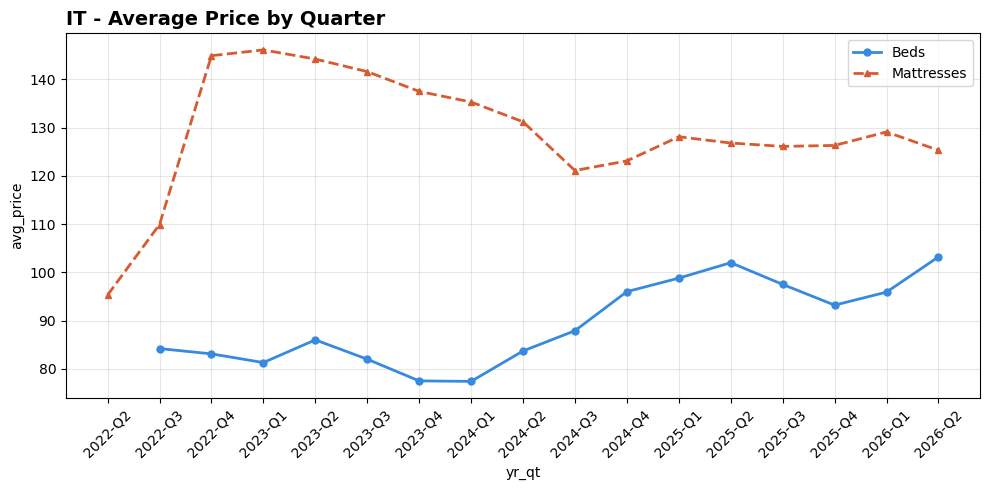

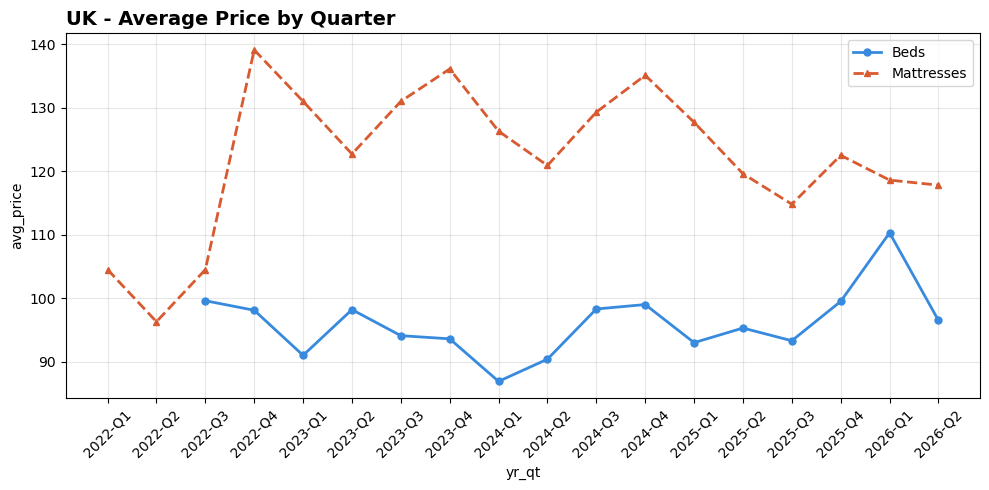

In [6]:
"""
EU BSR 평균 가격 시각화
- country별로 그래프를 하나씩 단독으로 생성
- 각 그래프에 category별(Beds / Mattresses) line plot
- x축: yr_qt (정렬됨), y축: avg_price
- 값이 없는 분기는 비워둠 (NaN gap)
"""

import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv("eu_bsr_price_0415.csv")

# 2. 카테고리명 통일
def normalize_category(c: str) -> str:
    return "Mattresses" if "attress" in c.lower() else "Beds"

df["cat"] = df["category"].apply(normalize_category)

# 3. 전체 분기 목록을 정렬된 순서로 확보 ("YYYY-Qn"은 사전순 정렬과 시간순 정렬이 일치)
all_quarters = sorted(df["yr_qt"].unique())

# 4. 스타일 설정
colors  = {"Beds": "#378ADD", "Mattresses": "#D85A30"}
styles  = {"Beds": "-",       "Mattresses": "--"}
markers = {"Beds": "o",       "Mattresses": "^"}

# 5. 국가별로 그래프를 하나씩 생성
countries = sorted(df["country"].unique())

for country in countries:
    fig, ax = plt.subplots(figsize=(10, 5))

    sub = df[df["country"] == country]

    for cat in ["Beds", "Mattresses"]:
        g = sub[sub["cat"] == cat].set_index("yr_qt")["avg_price"]
        # 전체 분기 인덱스에 맞춰 reindex → 누락 분기는 NaN으로 채워져 자동으로 gap 처리됨
        g = g.reindex(all_quarters)

        ax.plot(
            all_quarters, g.values,
            label=cat,
            color=colors[cat],
            linestyle=styles[cat],
            marker=markers[cat],
            markersize=5,
            linewidth=2,
        )

    ax.set_title(f"{country} - Average Price by Quarter",
                 fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("yr_qt")
    ax.set_ylabel("avg_price")
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=10)

    fig.tight_layout()
    fig.savefig(f"eu_bsr_price_{country}.png", dpi=150, bbox_inches="tight")
    plt.show()

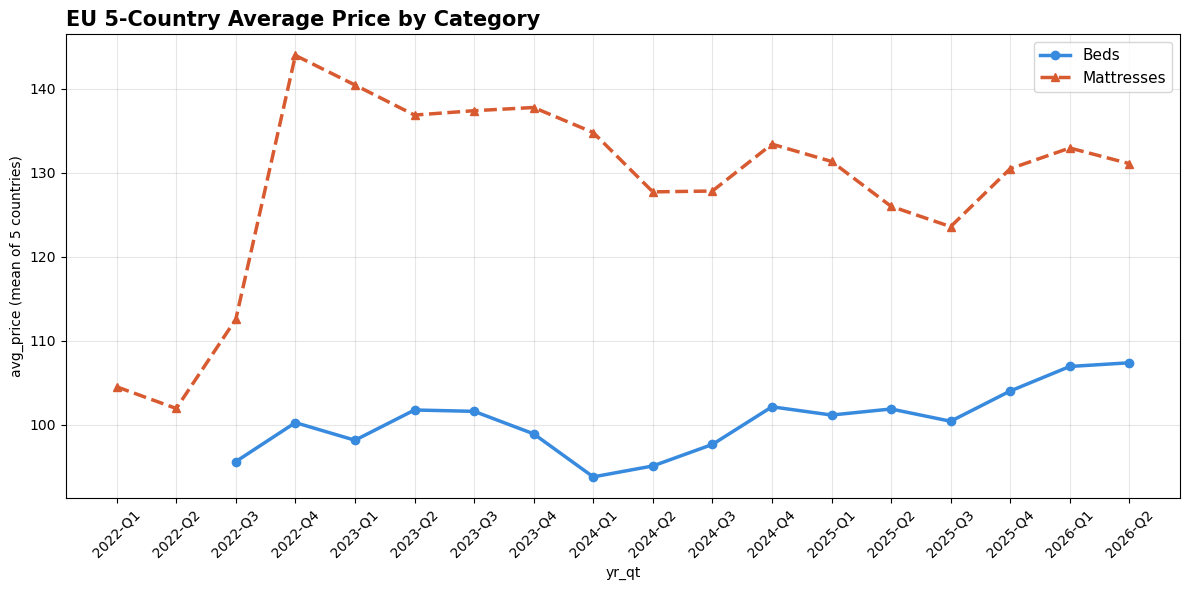

In [10]:
"""
EU BSR 평균 가격 시각화 (카테고리별 5개국 평균)
- 5개국(DE, ES, FR, IT, UK)의 분기별 avg_price를 카테고리별로 평균
- Category는 Beds / Mattresses 두 그룹으로 통일
- x축: yr_qt (정렬됨), y축: avg_price (5개국 평균)
- 값이 없는 분기는 비워둠 (NaN gap)
"""

import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv("eu_bsr_price_0415.csv")

# 2. 카테고리명 통일
def normalize_category(c: str) -> str:
    return "Mattresses" if "attress" in c.lower() else "Beds"

df["cat"] = df["category"].apply(normalize_category)

# 3. 카테고리 × 분기별로 5개국 평균 계산
agg = (
    df.groupby(["cat", "yr_qt"], as_index=False)["avg_price"]
      .mean()
)

# 4. 전체 분기 목록 (정렬)
all_quarters = sorted(df["yr_qt"].unique())

# 5. 스타일 설정
styles = {
    "Beds":       {"color": "#378ADD", "linestyle": "-",  "marker": "o"},
    "Mattresses": {"color": "#D85A30", "linestyle": "--", "marker": "^"},
}

# 6. 그래프 생성
fig, ax = plt.subplots(figsize=(12, 6))

for cat in ["Beds", "Mattresses"]:
    s = (
        agg[agg["cat"] == cat]
        .set_index("yr_qt")["avg_price"]
        .reindex(all_quarters)  # 누락 분기는 NaN -> 자동 gap
    )
    ax.plot(
        all_quarters, s.values,
        label=cat,
        color=styles[cat]["color"],
        linestyle=styles[cat]["linestyle"],
        marker=styles[cat]["marker"],
        markersize=6,
        linewidth=2.5,
    )

ax.set_title("EU 5-Country Average Price by Category",
             fontsize=15, fontweight="bold", loc="left")
ax.set_xlabel("yr_qt")
ax.set_ylabel("avg_price (mean of 5 countries)")
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=11)

fig.tight_layout()
fig.savefig("eu_bsr_price_avg_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

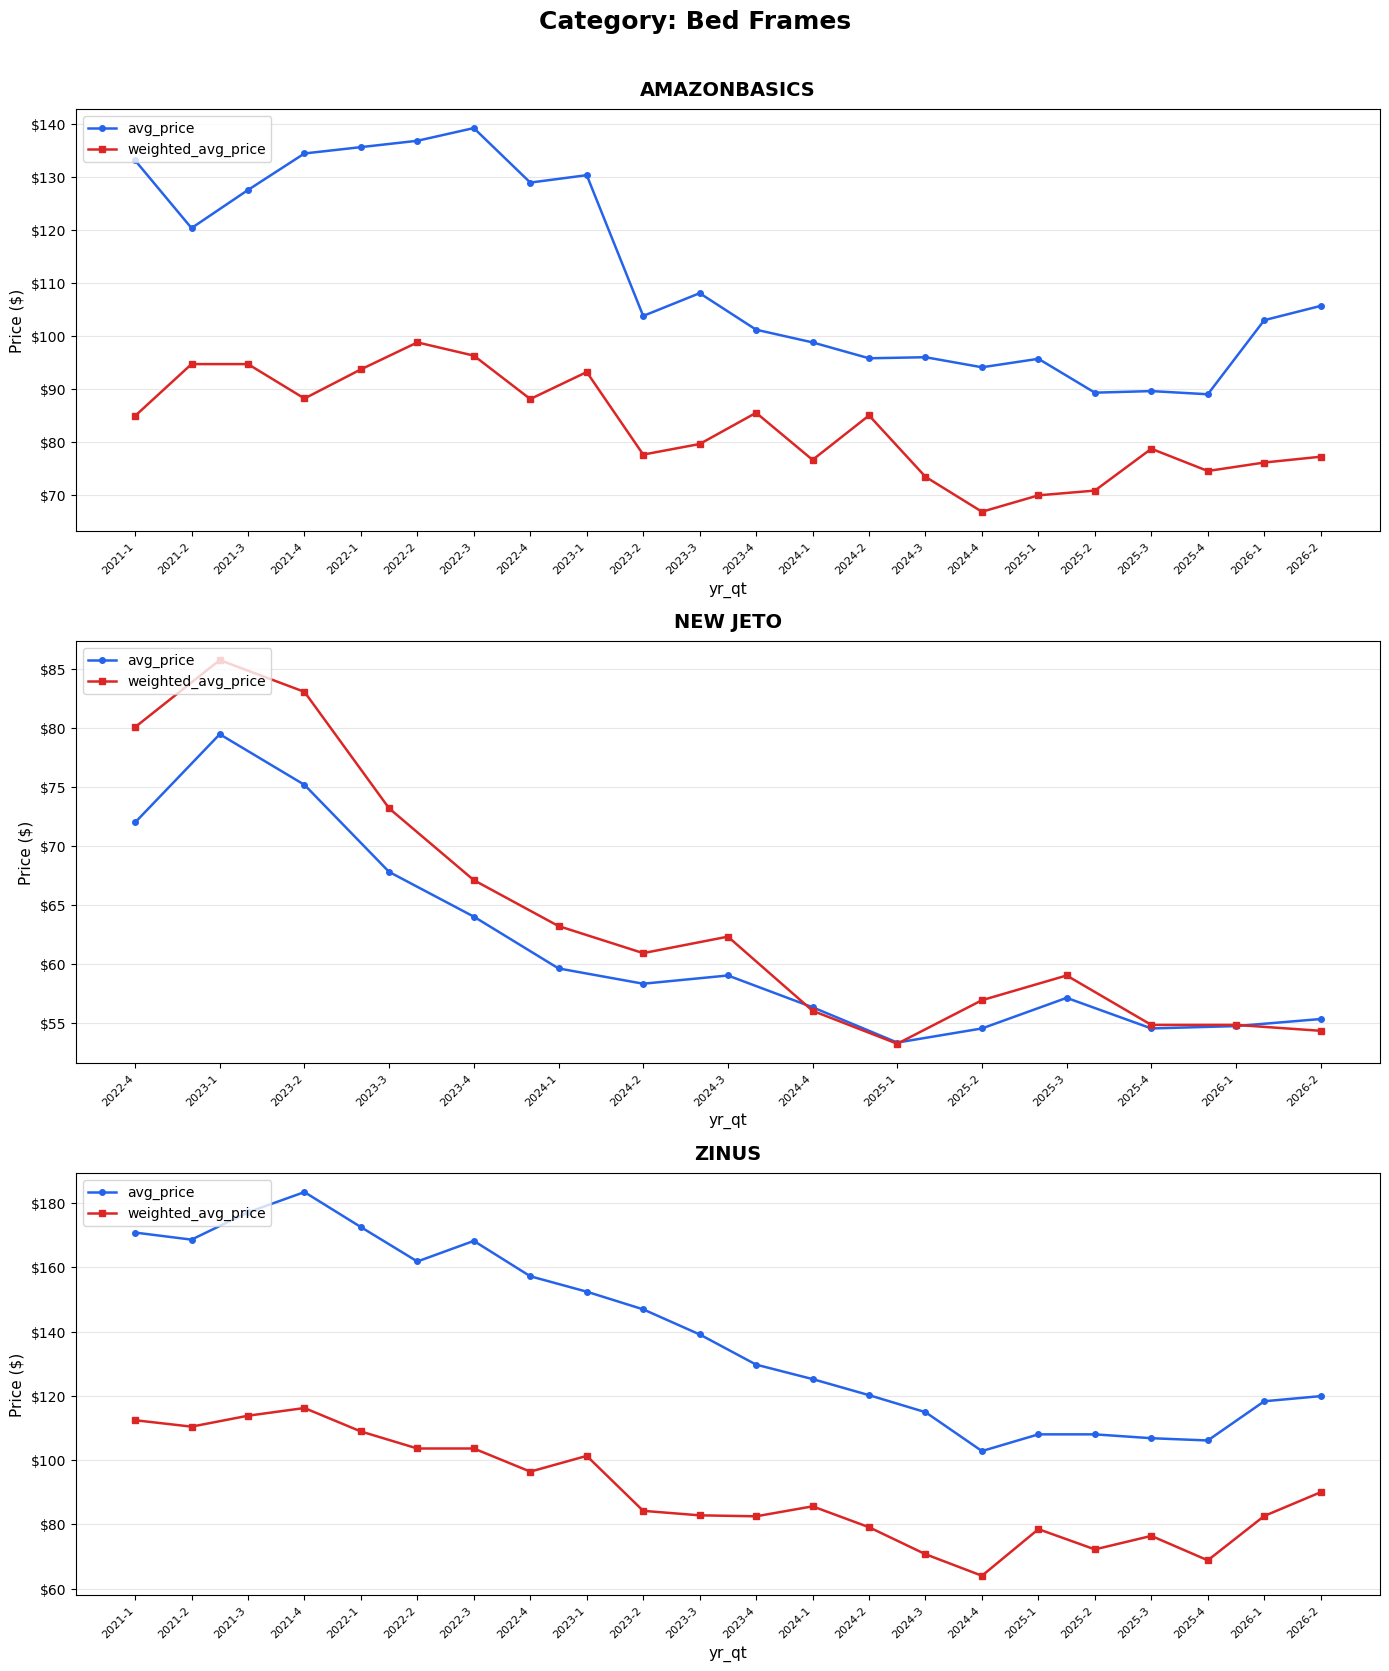

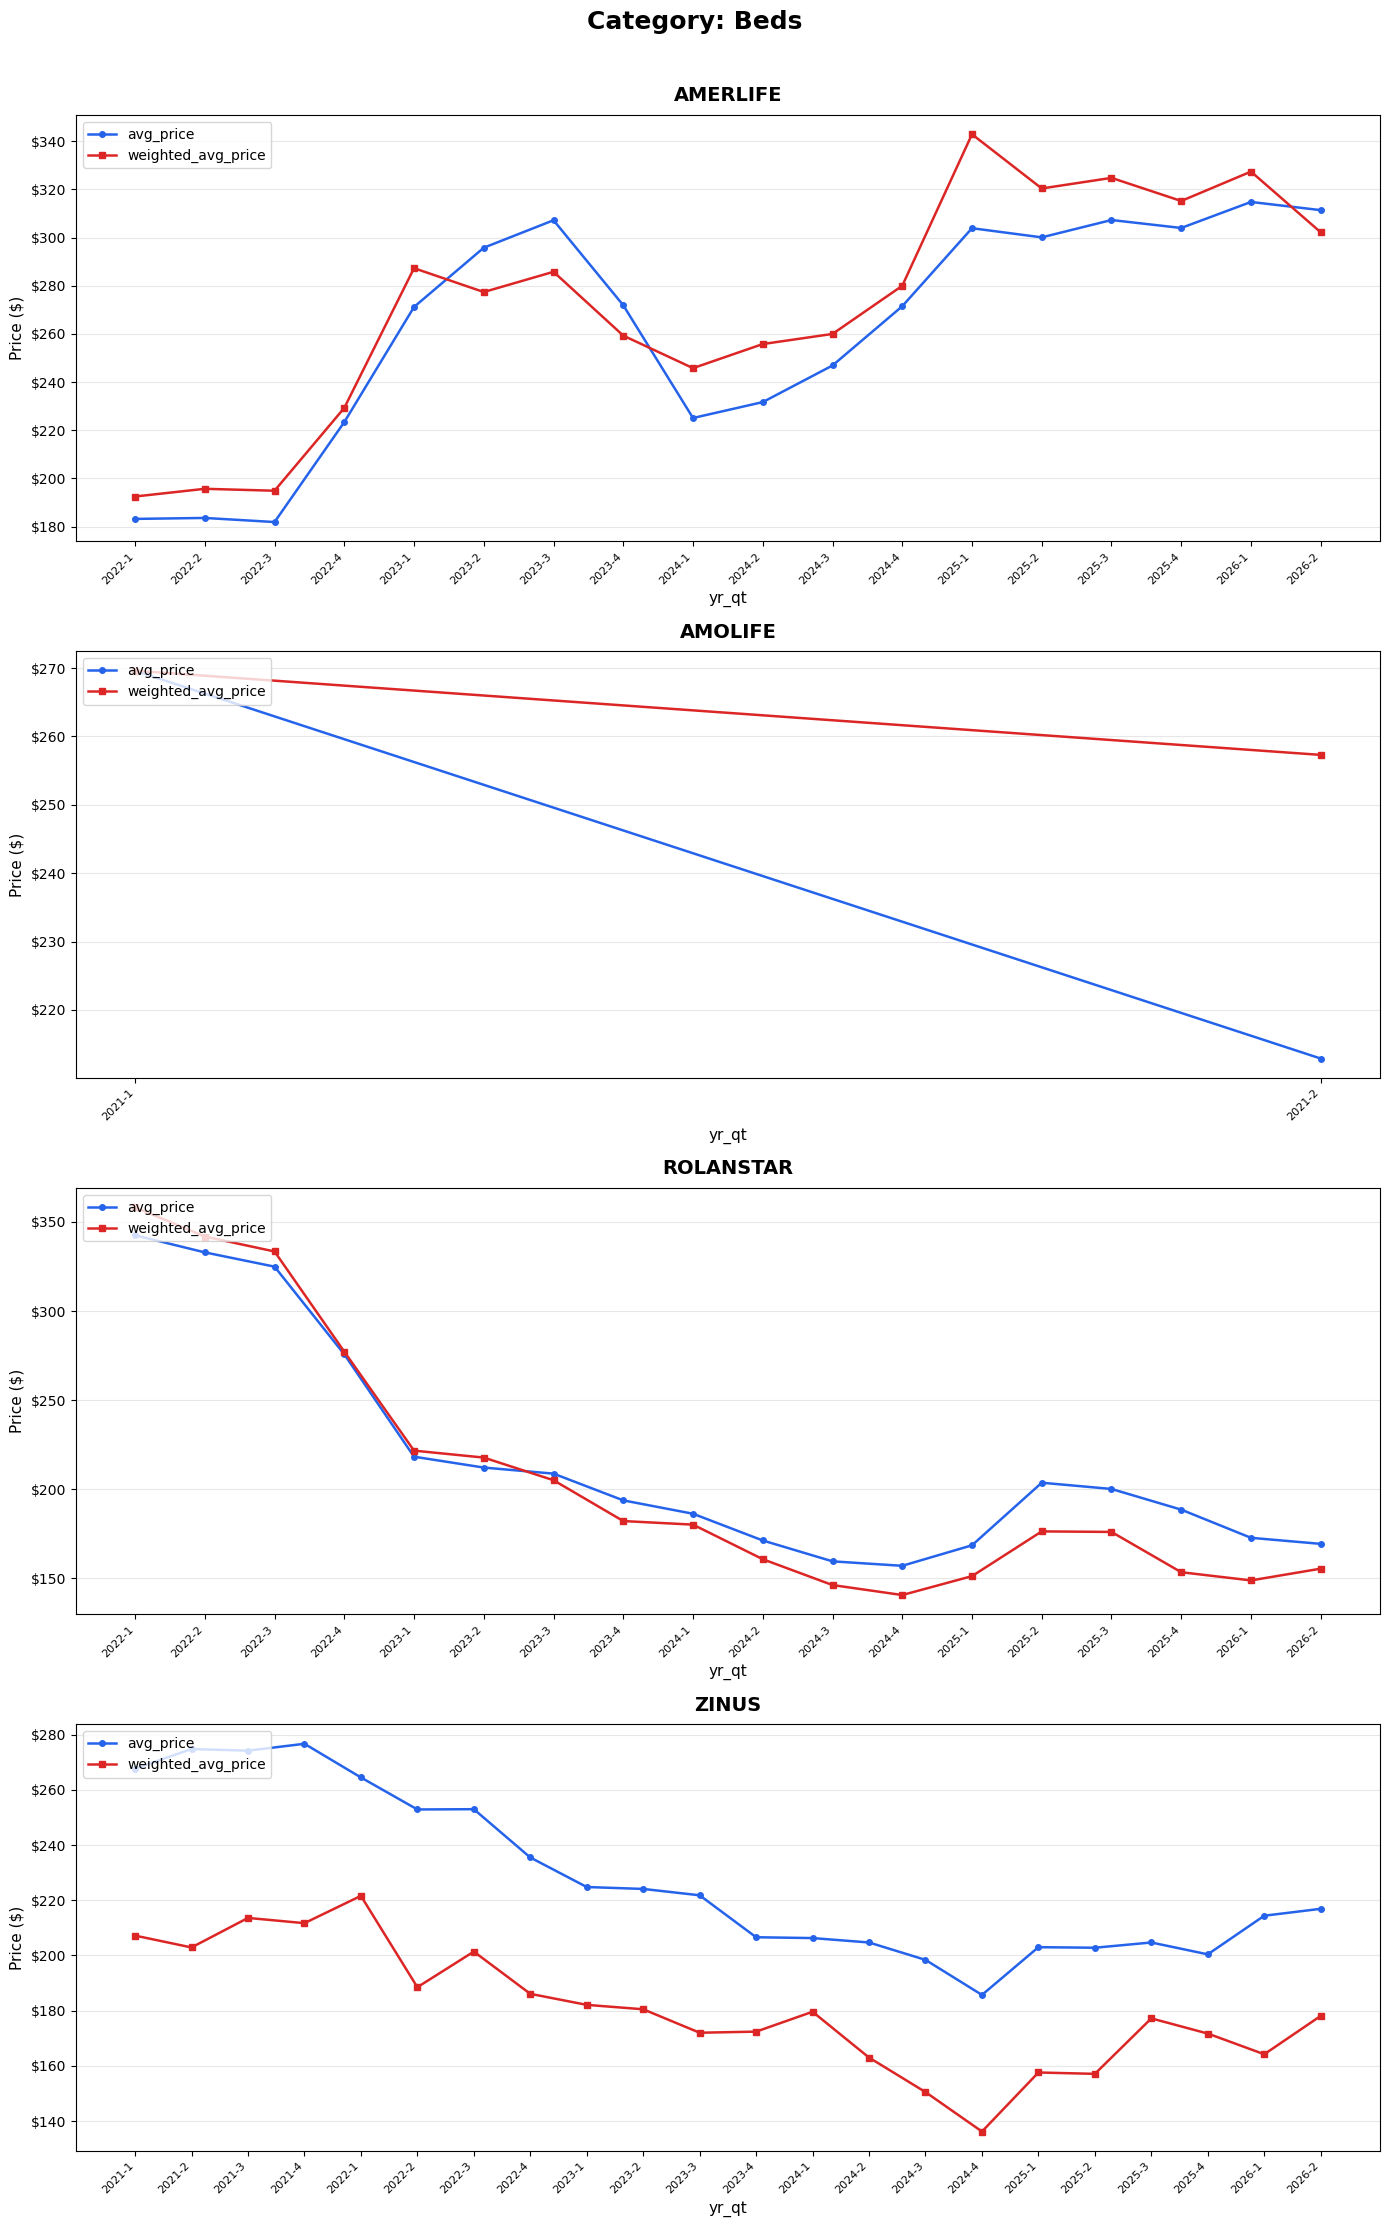

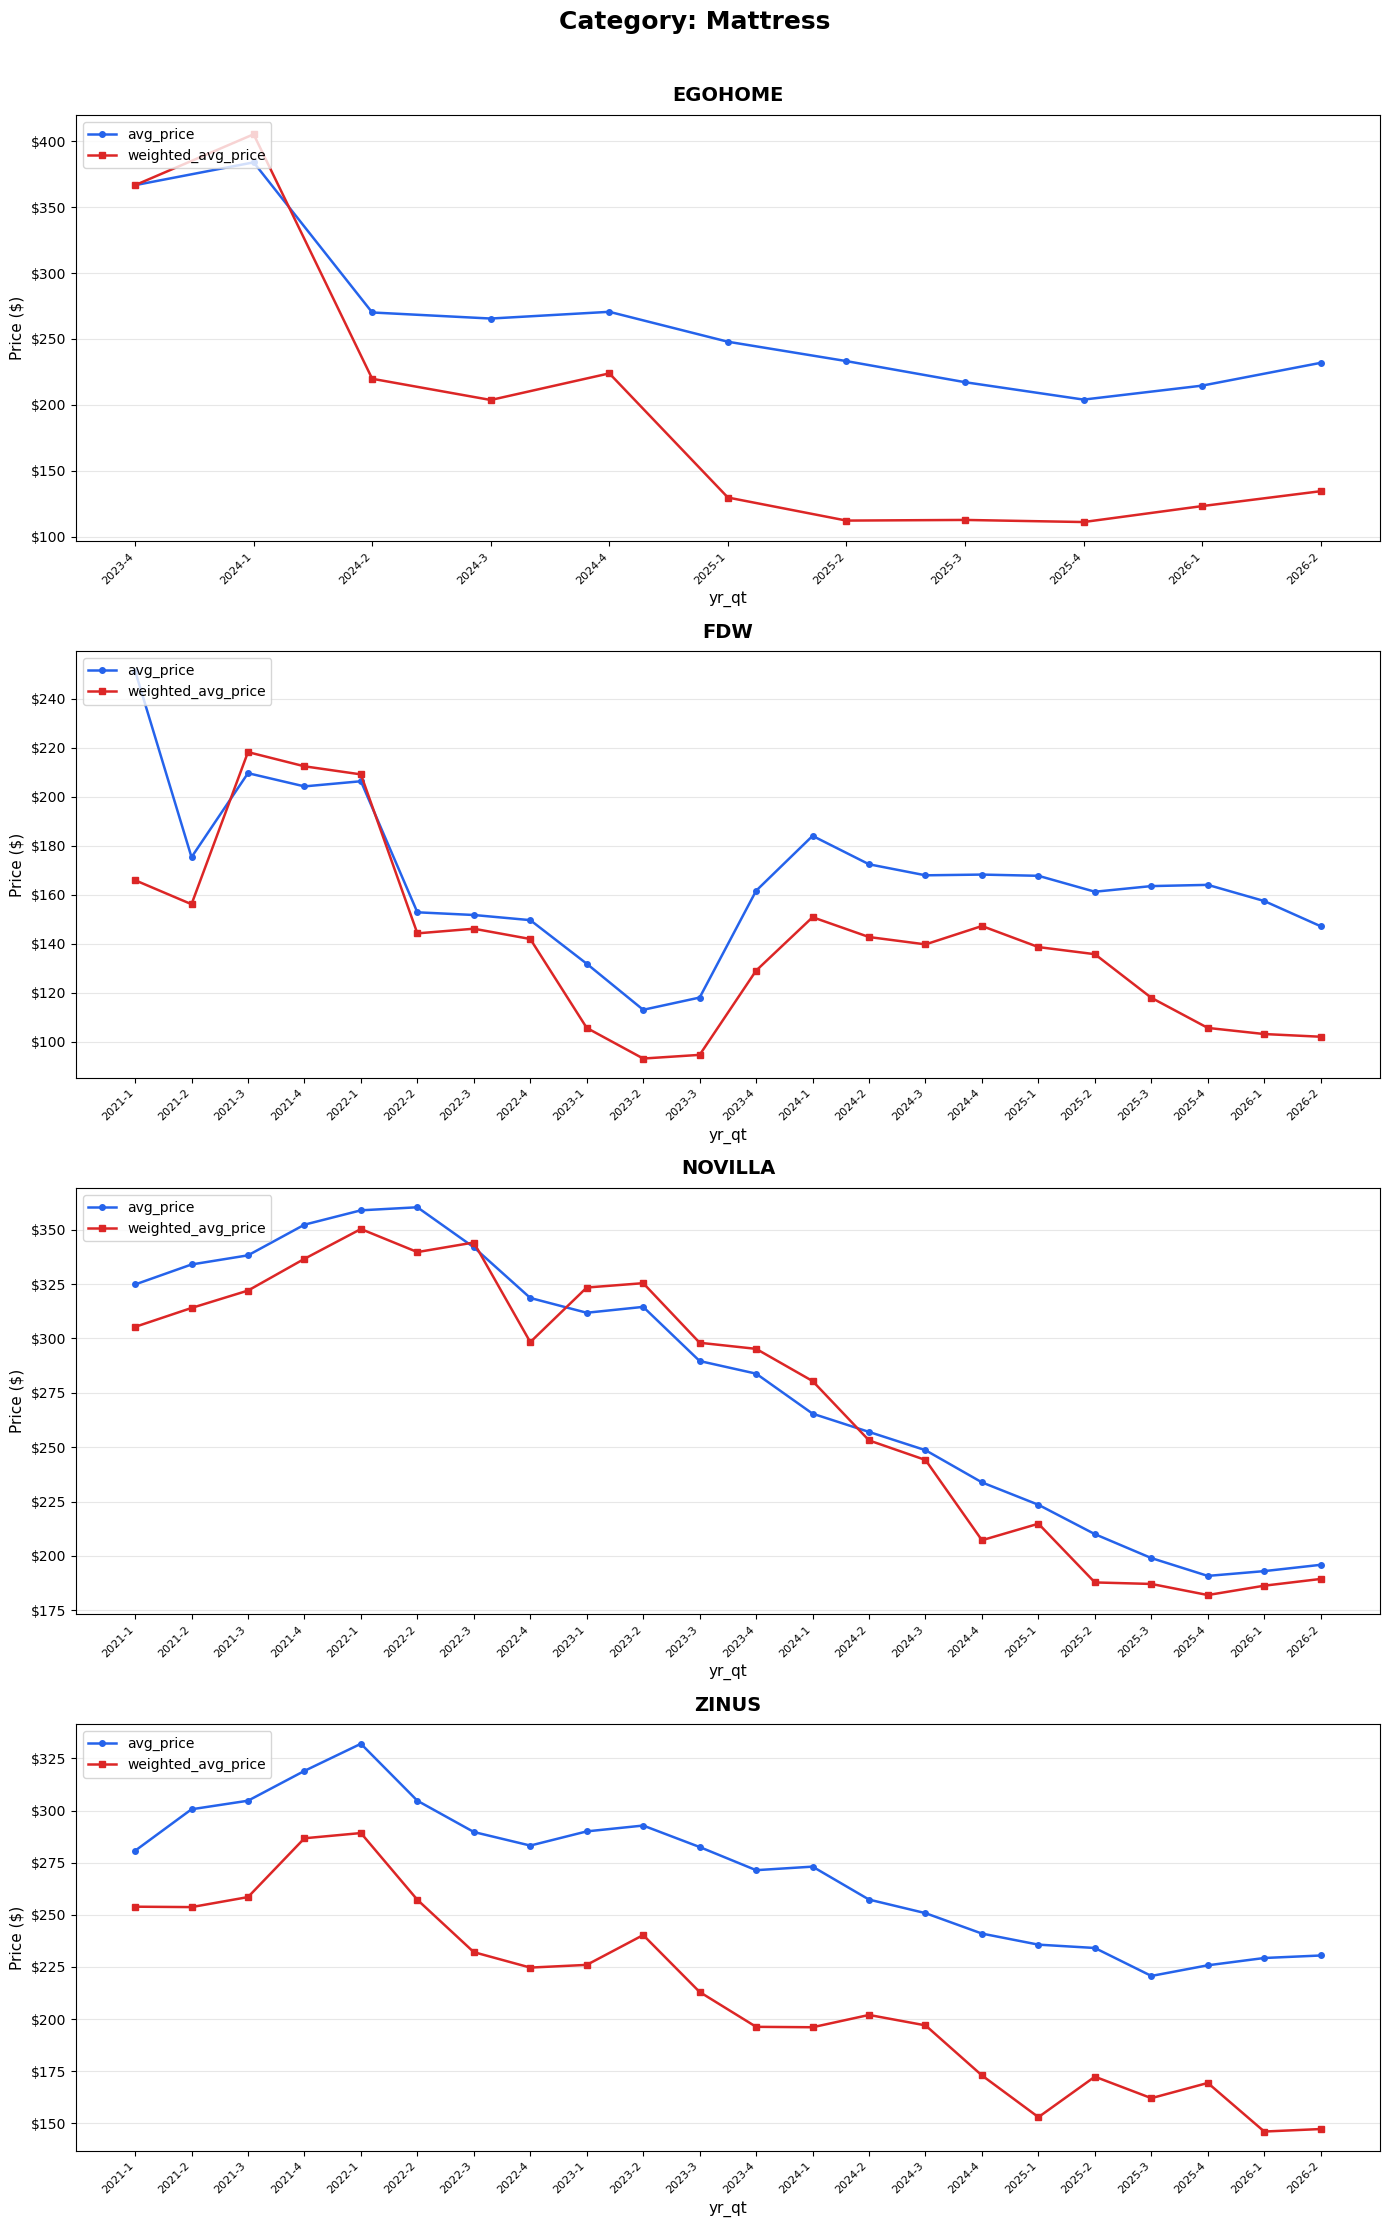

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 데이터 로드 ──
df = pd.read_csv("us_amz_comp_price_0415-1.csv")

# yr_qt 정렬용 키
df["sort_key"] = df["yr_qt"].apply(lambda x: int(x.split("-")[0]) * 10 + int(x.split("-")[1]))
df = df.sort_values("sort_key")

categories = sorted(df["category"].unique())

for cat in categories:
    df_cat = df[df["category"] == cat]
    brands = sorted(df_cat["brand"].unique())
    n_brands = len(brands)

    fig, axes = plt.subplots(n_brands, 1, figsize=(14, 5.5 * n_brands), squeeze=False)
    fig.suptitle(f"Category: {cat}", fontsize=18, fontweight="bold", y=1.01)

    for i, brand in enumerate(brands):
        ax = axes[i, 0]
        df_b = df_cat[df_cat["brand"] == brand].sort_values("sort_key")

        x = range(len(df_b))
        xticks = df_b["yr_qt"].values

        ax.plot(x, df_b["avg_price"], marker="o", markersize=4,
                linewidth=1.8, label="avg_price", color="#2563EB")
        ax.plot(x, df_b["weighted_avg_price"], marker="s", markersize=4,
                linewidth=1.8, label="weighted_avg_price", color="#DC2626")

        ax.set_title(f"{brand}", fontsize=14, fontweight="bold", pad=10)
        ax.set_xlabel("yr_qt", fontsize=11)
        ax.set_ylabel("Price ($)", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(xticks, rotation=45, ha="right", fontsize=8)
        ax.legend(fontsize=10, loc="upper left")
        ax.grid(axis="y", alpha=0.3)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.0f"))

    plt.tight_layout()
    plt.show()

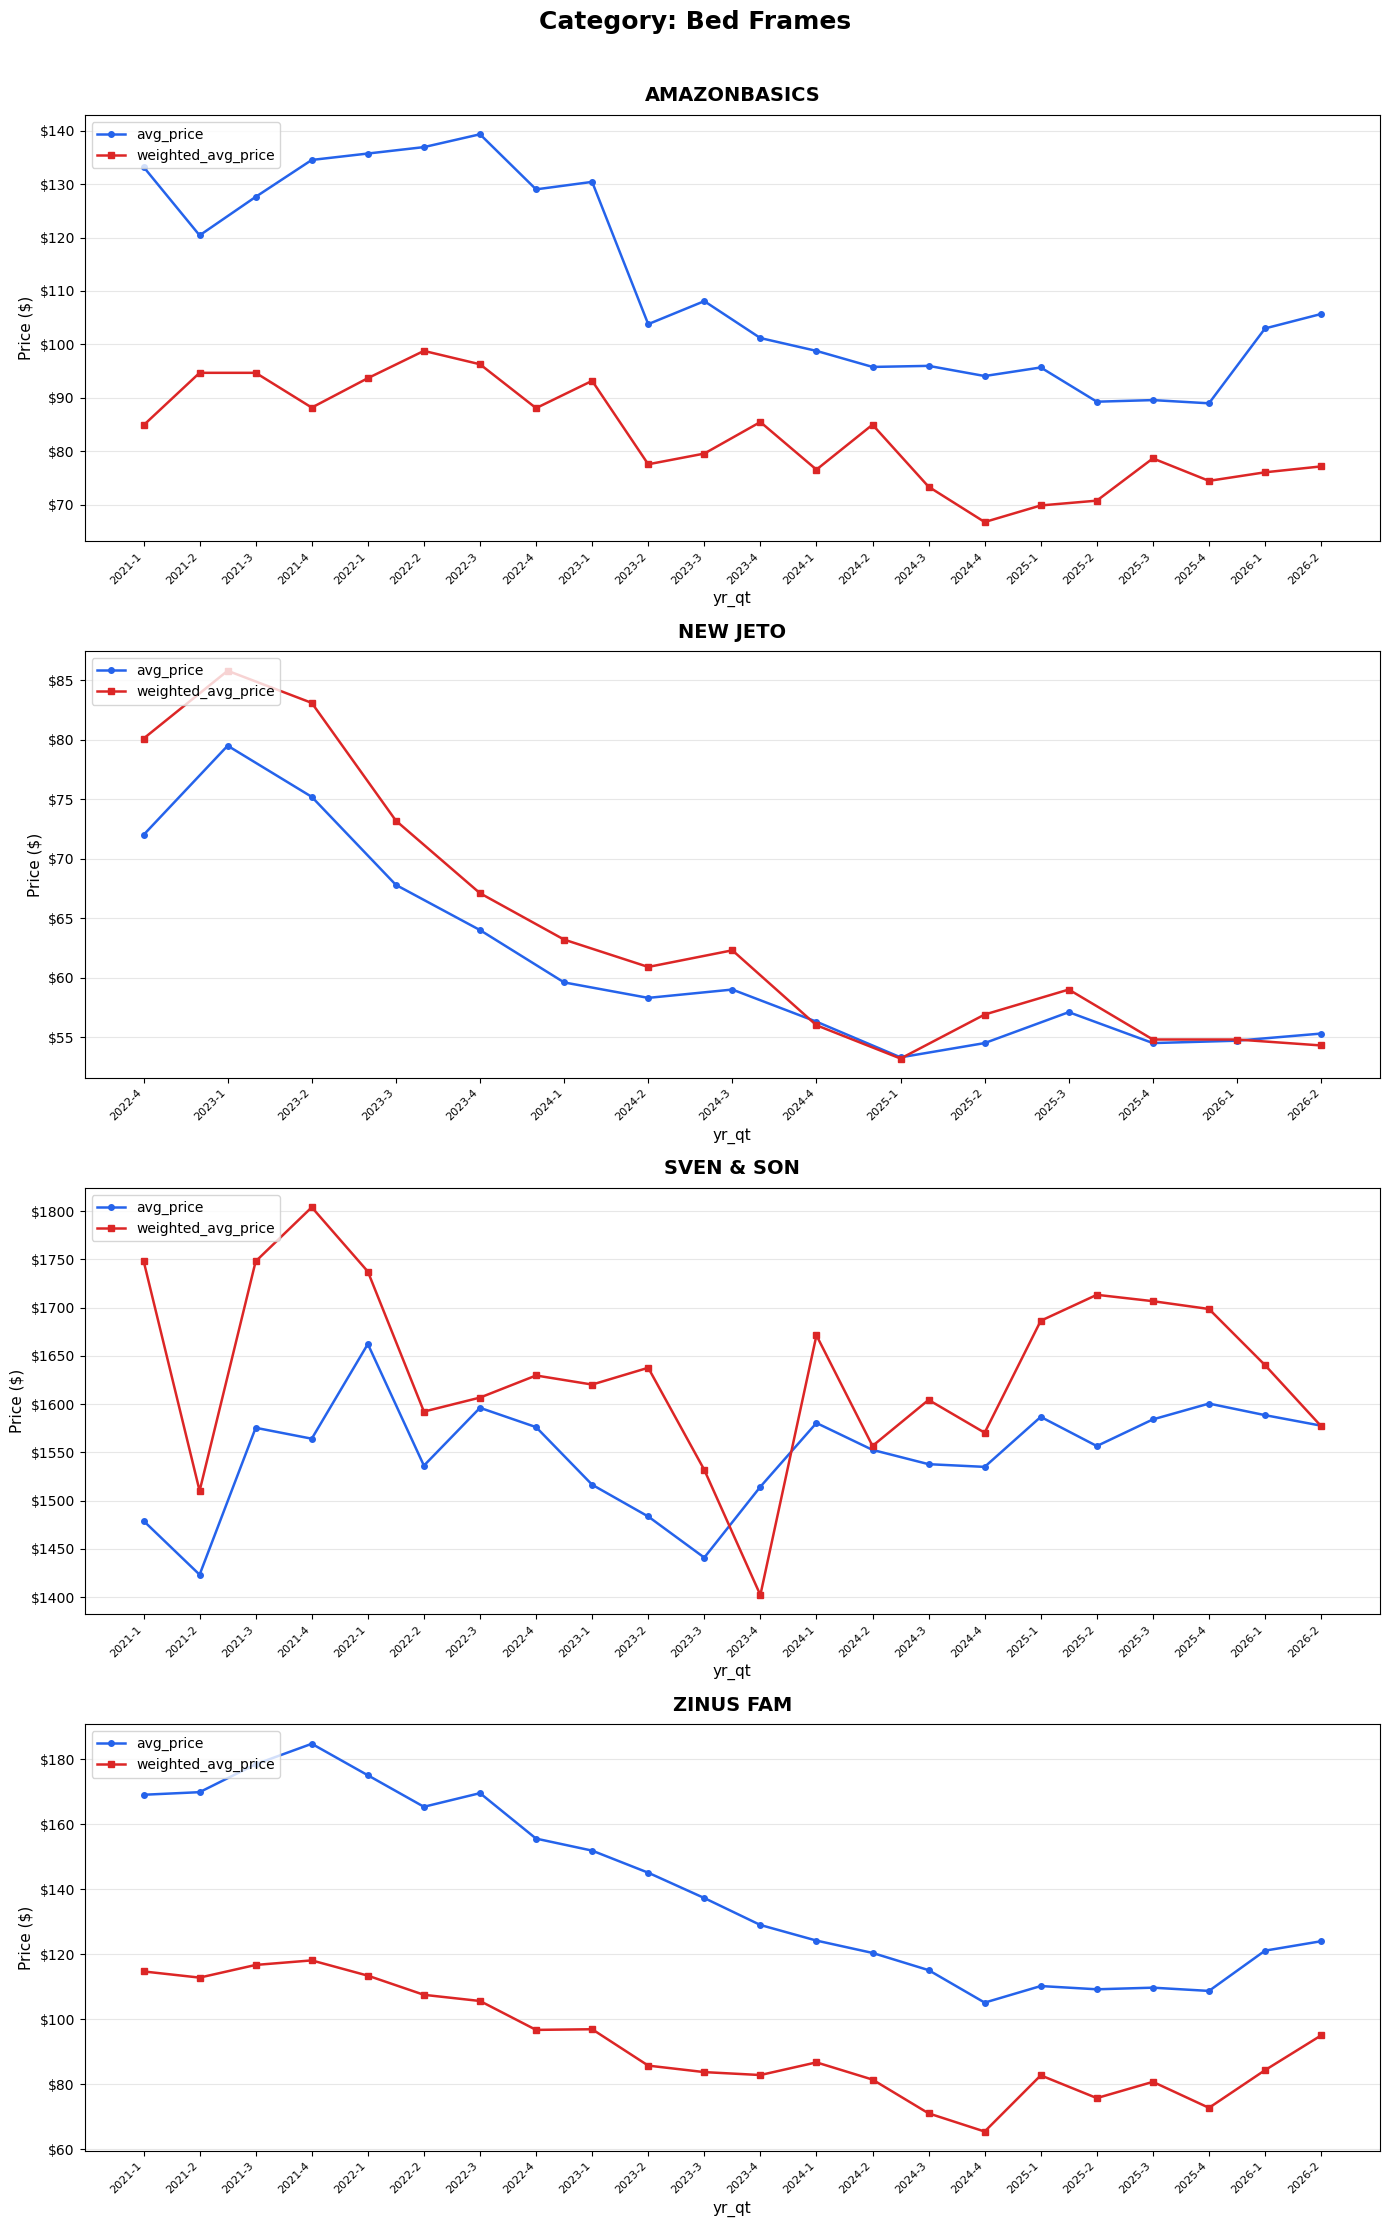

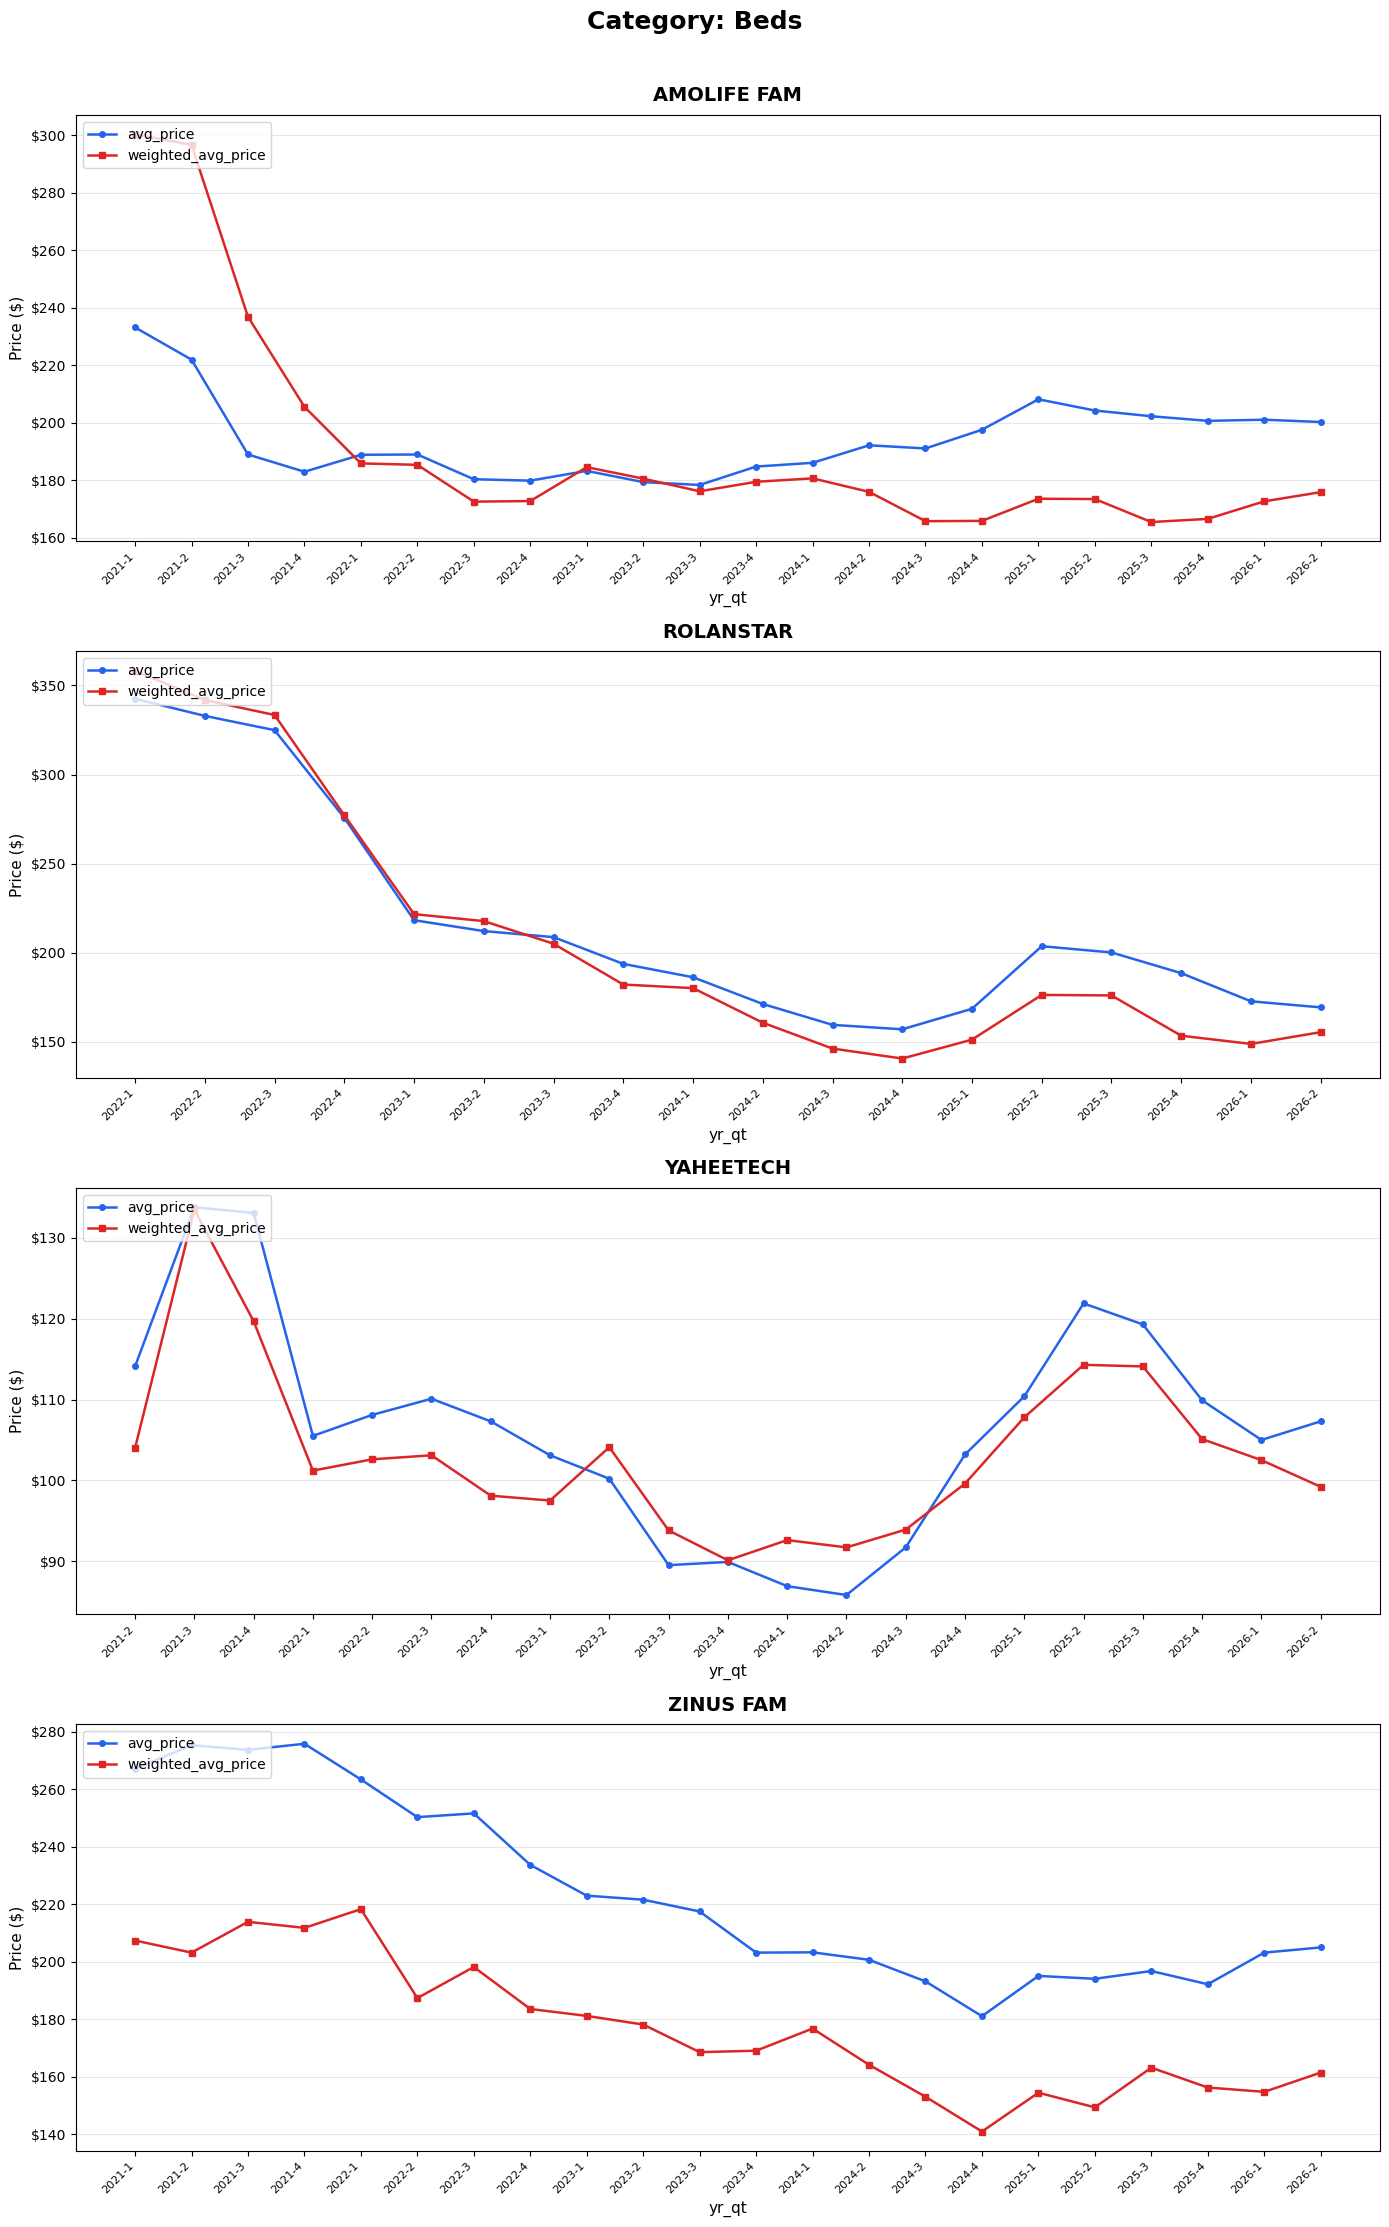

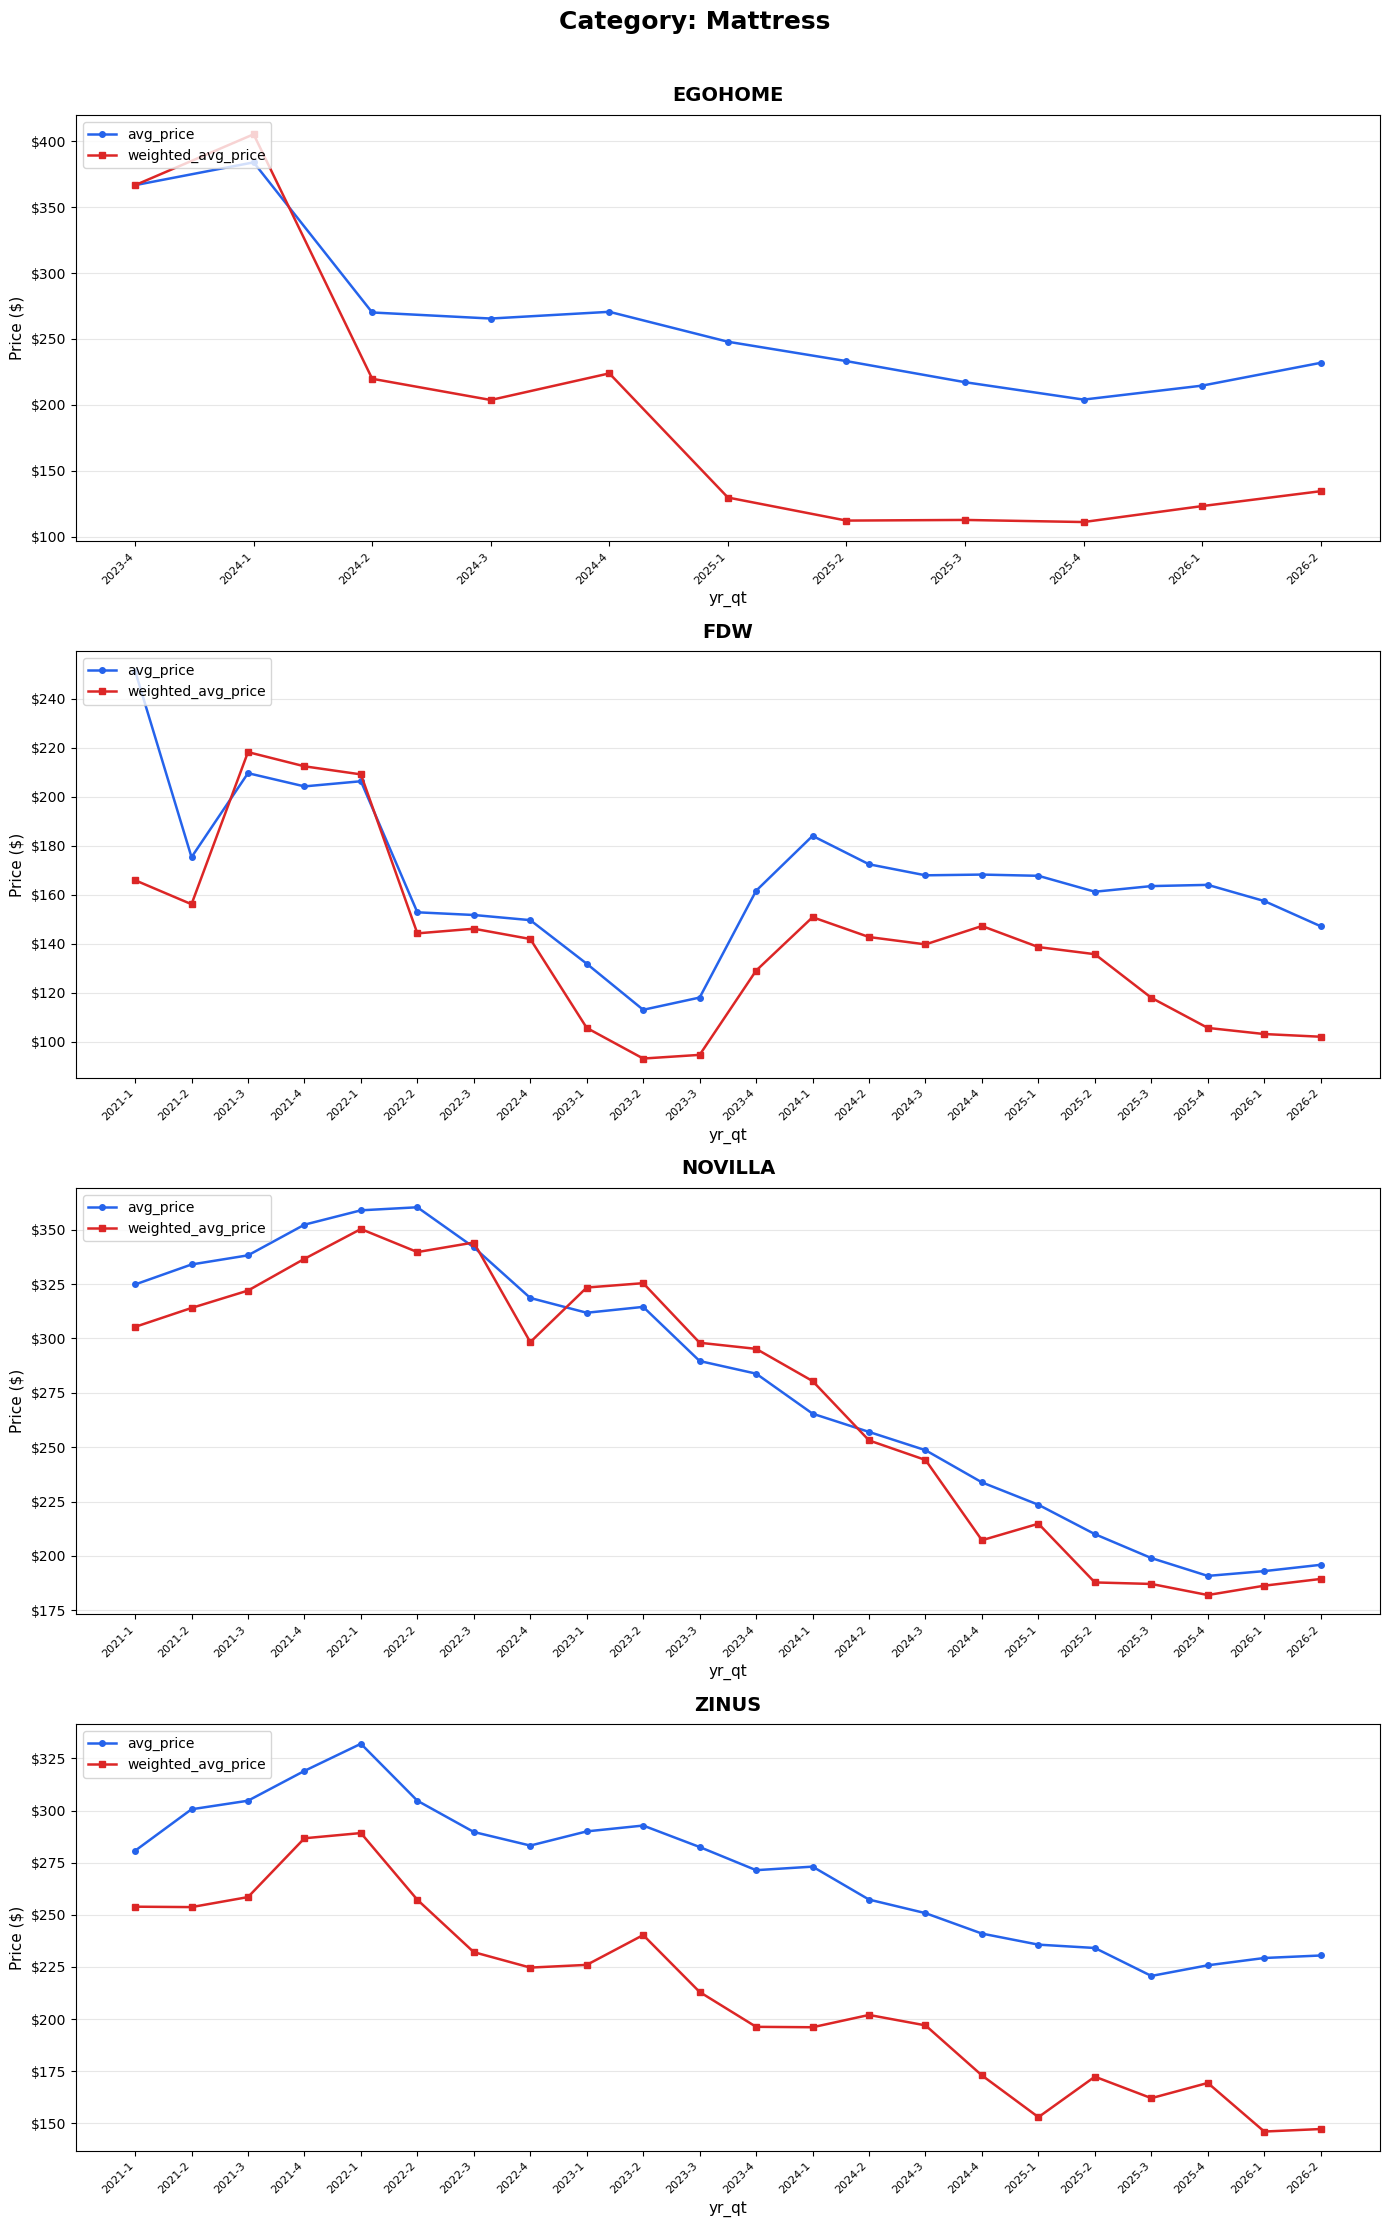

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 데이터 로드 ──
df = pd.read_csv("us_amz_comp_price_0415-2.csv")

# yr_qt 정렬용 키
df["sort_key"] = df["yr_qt"].apply(lambda x: int(x.split("-")[0]) * 10 + int(x.split("-")[1]))
df = df.sort_values("sort_key")

categories = sorted(df["category"].unique())

for cat in categories:
    df_cat = df[df["category"] == cat]
    brands = sorted(df_cat["brand_fam"].unique())
    n_brands = len(brands)

    fig, axes = plt.subplots(n_brands, 1, figsize=(14, 5.5 * n_brands), squeeze=False)
    fig.suptitle(f"Category: {cat}", fontsize=18, fontweight="bold", y=1.01)

    for i, brand in enumerate(brands):
        ax = axes[i, 0]
        df_b = df_cat[df_cat["brand_fam"] == brand].sort_values("sort_key")

        x = range(len(df_b))
        xticks = df_b["yr_qt"].values

        ax.plot(x, df_b["avg_price"], marker="o", markersize=4,
                linewidth=1.8, label="avg_price", color="#2563EB")
        ax.plot(x, df_b["weighted_avg_price"], marker="s", markersize=4,
                linewidth=1.8, label="weighted_avg_price", color="#DC2626")

        ax.set_title(f"{brand}", fontsize=14, fontweight="bold", pad=10)
        ax.set_xlabel("yr_qt", fontsize=11)
        ax.set_ylabel("Price ($)", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(xticks, rotation=45, ha="right", fontsize=8)
        ax.legend(fontsize=10, loc="upper left")
        ax.grid(axis="y", alpha=0.3)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.0f"))

    plt.tight_layout()
    plt.show()